Make Use of The Wisconsin Breast Cancer Dataset to Find if a Tumor is Malignant or Beningn

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign
print(data.target_names)

['malignant' 'benign']



Class Distribution:

       Class  Count  Probability
0  malignant    212     0.372583
1     benign    357     0.627417


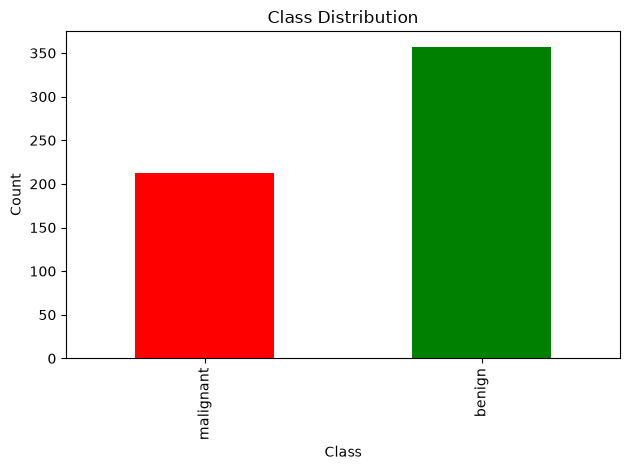

In [7]:
class_counts = y.value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class": ["malignant", "benign"],
    "Count": class_counts.values,
    "Probability": class_counts.values / len(y),
})

print("\nClass Distribution:\n")
print(class_distribution)

class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    color=["red", "green"],
    legend=False,
)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
)

model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42),
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 98.25%

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:

[[41  1]
 [ 1 71]]


In [10]:
probabilities = model.predict_proba(X_test)

results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:, 0],
    "P_benign": probabilities[:, 1],
})

results["Actual_label"] = results["Actual_class"].map({0: "malignant", 1: "benign"})

print("\nFirst 10 Probability Results:\n")
print(results[["Actual_class", "Actual_label", "P_malignant", "P_benign"]].head(10))

for threshold in [0.3, 0.5, 0.7]:
    predicted_malignant = (results["P_malignant"] >= threshold).astype(int)
    results[f"Predicted_malignant_{threshold}"] = predicted_malignant
    results[f"Predicted_label_{threshold}"] = predicted_malignant.map({1: "malignant", 0: "benign"})

    y_pred_threshold = (probabilities[:, 0] >= threshold).astype(int)

    print(f"\nConfusion Matrix with Threshold {threshold}:\n")
    print(confusion_matrix(y_test, y_pred_threshold))

    print(f"\nSample Predictions for Threshold {threshold}:\n")
    print(
        results[
            [
            "Actual_label",
            "P_malignant",
            "P_benign",
            f"Predicted_label_{threshold}",
            ]
        ].head(10)
        )


First 10 Probability Results:

   Actual_class Actual_label  P_malignant      P_benign
0             0    malignant     1.000000  5.888242e-08
1             1       benign     0.000011  9.999887e-01
2             0    malignant     0.993589  6.410825e-03
3             1       benign     0.466491  5.335085e-01
4             0    malignant     1.000000  6.525001e-10
5             1       benign     0.007840  9.921604e-01
6             1       benign     0.000017  9.999828e-01
7             0    malignant     0.999999  5.635275e-07
8             0    malignant     0.999946  5.431637e-05
9             0    malignant     1.000000  8.041849e-11

Confusion Matrix with Threshold 0.3:

[[ 1 41]
 [67  5]]

Sample Predictions for Threshold 0.3:

  Actual_label  P_malignant      P_benign Predicted_label_0.3
0    malignant     1.000000  5.888242e-08           malignant
1       benign     0.000011  9.999887e-01              benign
2    malignant     0.993589  6.410825e-03           malignant
3     

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score



probabilities = model.predict_proba(X_test)
# 0 = malignant, 1 = benign
y_true_malignant = (y_test == 0).astype(int)

for threshold in [0.3, 0.5, 0.7]:
    y_pred_malignant = (probabilities[:, 0] >= threshold).astype(int)

    precision = precision_score(y_true_malignant, y_pred_malignant, zero_division=0)
    recall = recall_score(y_true_malignant, y_pred_malignant, zero_division=0)
    f1 = f1_score(y_true_malignant, y_pred_malignant, zero_division=0)
    accuracy = accuracy_score(y_true_malignant, y_pred_malignant)

    print(f"\nMetrics for Threshold {threshold}:")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"\nClassification Report for Threshold {threshold}:\n")
    print(classification_report(y_true_malignant, y_pred_malignant, target_names=["benign", "malignant"]))


Metrics for Threshold 0.3:
Precision: 0.89
Recall: 0.98
F1 Score: 0.93
Accuracy: 0.95

Classification Report for Threshold 0.3:

              precision    recall  f1-score   support

      benign       0.99      0.93      0.96        72
   malignant       0.89      0.98      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114


Metrics for Threshold 0.5:
Precision: 0.98
Recall: 0.98
F1 Score: 0.98
Accuracy: 0.98

Classification Report for Threshold 0.5:

              precision    recall  f1-score   support

      benign       0.99      0.99      0.99        72
   malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Metrics for Threshold 0.7:
Precision: 1.00
Recall: 0.95
F1 Score: 0.98
Accuracy: 0.98

In [12]:
probabilities = model.predict_proba(X_test)
y_true_malignant = (y_test == 0).astype(int)

report_data = []

for threshold in [0.1, 0.3, 0.5, 0.7, 0.9]:
    y_pred_malignant = (probabilities[:, 0] >= threshold).astype(int)

    precision = precision_score(y_true_malignant, y_pred_malignant, zero_division=0)
    recall = recall_score(y_true_malignant, y_pred_malignant, zero_division=0)
    f1 = f1_score(y_true_malignant, y_pred_malignant, zero_division=0)
    accuracy = accuracy_score(y_true_malignant, y_pred_malignant)
    tn, fp, fn, tp = confusion_matrix(y_true_malignant, y_pred_malignant).ravel()

    report_data.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Accuracy": accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
        })

report_df = pd.DataFrame(report_data)
print("\nClassification Report and Confusion Matrix for Different Thresholds:\n")
print(report_df.to_string(index=False))


Classification Report and Confusion Matrix for Different Thresholds:

 Threshold  Precision   Recall  F1 Score  Accuracy  TN  FP  FN  TP
       0.1   0.788462 0.976190  0.872340  0.894737  61  11   1  41
       0.3   0.891304 0.976190  0.931818  0.947368  67   5   1  41
       0.5   0.976190 0.976190  0.976190  0.982456  71   1   1  41
       0.7   1.000000 0.952381  0.975610  0.982456  72   0   2  40
       0.9   1.000000 0.880952  0.936709  0.956140  72   0   5  37
